# Data Mining / Prospecção de Dados
## Sara C. Madeira, 2025/2026
## Project 1 - Pattern Mining

## Team Identification

GROUP NN

Students:
- Student 1 - n_student1
- Student 2 - n_student2
- Student 3 - n_student3

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── reproducibility seed ──────────────────────────────────────────────────────
RANDOM_STATE = 42

## 1.1. Load and Pre-process Data

Design decisions:
- We encode items as product sub-categories (the leaf node of `appliances.kitchen.juice`) rather than raw item IDs.  This reduces the cardinality of the item universe, makes the patterns human-readable, and is much more actionable.
- We drop the `Context` column from clicks and the `Price`/`Quantity` columns from purchases.
- Sessions that contain only one distinct subcategory are discarded since single-item sessions contribute nothing to co-occurrence mining.
- For the click-purchase merged dataset we concatenate all (session, subcategory) pairs from both files so that a session may contain both clicked and purchased items.

In [2]:
# Load raw files 
products  = pd.read_csv('datasets/store-products.csv',
                        names=['item_id', 'category_path'])
clicks    = pd.read_csv('datasets/store-clicks.csv',
                        names=['session_id', 'timestamp', 'item_id', 'context'])
purchases = pd.read_csv('datasets/store-purchases.csv',
                        names=['session_id', 'timestamp', 'item_id', 'price', 'quantity'])

print(f'Products  : {products.shape[0]:,} rows')
print(f'Clicks    : {clicks.shape[0]:,} rows  |  {clicks["session_id"].nunique():,} sessions')
print(f'Purchases : {purchases.shape[0]:,} rows  |  {purchases["session_id"].nunique():,} sessions')

Products  : 20,704,559 rows
Clicks    : 20,704,559 rows  |  5,613,499 sessions
Purchases : 679,489 rows  |  318,444 sessions


In [3]:
# Extract subcategory label from category_path 
#   e.g. 'appliances.kitchen.juice' → 'juice'
products['subcat'] = products['category_path'].apply(lambda x: x.split('.')[-1])
products['cat']    = products['category_path'].apply(lambda x: x.split('.')[0])

item_subcat = products.set_index('item_id')['subcat'].to_dict()
item_cat    = products.set_index('item_id')['cat'].to_dict()

print('Unique subcategories :', products['subcat'].nunique())
print('Unique top categories:', products['cat'].nunique())

Unique subcategories : 121
Unique top categories: 13


In [4]:
# Parse timestamps and add day-of-week helper columns 
for df in [clicks, purchases]:
    df['ts']         = pd.to_datetime(df['timestamp'], utc=True)
    df['dayofweek']  = df['ts'].dt.dayofweek          # Mon=0 … Sun=6
    df['is_weekend'] = df['dayofweek'] >= 5

clicks.head(3)

,session_id,timestamp,item_id,context,ts,dayofweek,is_weekend
0,1,2014-04-07T10:51:09.277Z,214536502,0,2014-04-07 10:51:09.277000+00:00,0,False
1,1,2014-04-07T10:54:09.868Z,214536500,0,2014-04-07 10:54:09.868000+00:00,0,False
2,1,2014-04-07T10:54:46.998Z,214536506,0,2014-04-07 10:54:46.998000+00:00,0,False


In [5]:
# map item_id → subcat
clicks['subcat']    = clicks['item_id'].map(item_subcat)
purchases['subcat'] = purchases['item_id'].map(item_subcat)

clicks    = clicks.dropna(subset=['subcat'])
purchases = purchases.dropna(subset=['subcat'])

print('Clicks after subcat mapping    :', len(clicks))
print('Purchases after subcat mapping :', len(purchases))

Clicks after subcat mapping    : 20704559
Purchases after subcat mapping : 679489


In [7]:
# Helper: build a Boolean transaction DataFrame
def build_transactions(df, session_col='session_id', item_col='subcat',
                        min_items=2, sample_n=None, random_state=RANDOM_STATE):
    """
    Given a long-format DataFrame (one row per event), aggregate by session
    and return a Boolean transaction DataFrame suitable for MLxtend.

    Parameters
    ----------
    min_items  : minimum number of *distinct* items a session must contain
    sample_n   : if set, randomly sample this many sessions (for speed)
    """
    # Group into lists of unique items per session
    grouped = (
        df[[session_col, item_col]]
        .drop_duplicates()
        .groupby(session_col)[item_col]
        .apply(list)
        .reset_index(drop=True)
    )
    # Filter sessions with too few items
    grouped = grouped[grouped.apply(len) >= min_items]

    if sample_n is not None and len(grouped) > sample_n:
        grouped = grouped.sample(sample_n, random_state=random_state)

    te = TransactionEncoder()
    te_array = te.fit_transform(grouped.tolist())
    return pd.DataFrame(te_array, columns=te.columns_)


SAMPLE_N = 20_000_000

print('Building click transactions …')
te_clicks = build_transactions(clicks) # ), sample_n=SAMPLE_N)

print('Building purchase transactions …')
te_purchases = build_transactions(purchases) # ,sample_n=SAMPLE_N)          # purchases dataset is smaller

# Click-purchase: tag subcategories so that a clicked item and a purchased item
# remain distinguishable in the merged space.
clicks_tagged    = clicks.copy();    clicks_tagged['subcat']    = 'C_' + clicks['subcat']
purchases_tagged = purchases.copy(); purchases_tagged['subcat'] = 'P_' + purchases['subcat']
merged = pd.concat([clicks_tagged[['session_id','subcat','is_weekend']],
                    purchases_tagged[['session_id','subcat','is_weekend']]])

print('Building click-purchase transactions …')
te_cp = build_transactions(merged) #, sample_n=SAMPLE_N)

print(f'\nTransaction matrix shapes:')
print(f'  Clicks          : {te_clicks.shape}')
print(f'  Purchases       : {te_purchases.shape}')
print(f'  Click-Purchase  : {te_cp.shape}')

Building click transactions …
Building purchase transactions …
Building click-purchase transactions …

Transaction matrix shapes:
  Clicks          : (3862509, 121)
  Purchases       : (121943, 121)
  Click-Purchase  : (3955721, 242)


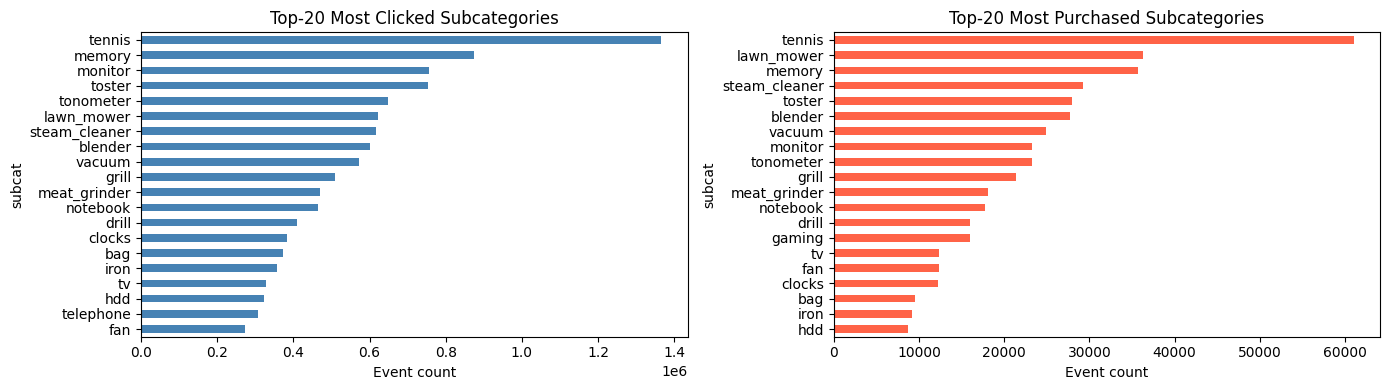


Top-5 most clicked    : ['tennis', 'memory', 'monitor', 'toster', 'tonometer']
Top-5 most purchased  : ['tennis', 'lawn_mower', 'memory', 'steam_cleaner', 'toster']


In [8]:
# copmute most popular items
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_clicks = clicks['subcat'].value_counts().head(20)
top_purchases = purchases['subcat'].value_counts().head(20)

top_clicks.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top-20 Most Clicked Subcategories')
axes[0].set_xlabel('Event count')

top_purchases.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].invert_yaxis()
axes[1].set_title('Top-20 Most Purchased Subcategories')
axes[1].set_xlabel('Event count')

plt.tight_layout()
plt.savefig('top_items.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nTop-5 most clicked    :', top_clicks.index[:5].tolist())
print('Top-5 most purchased  :', top_purchases.index[:5].tolist())

## 1.2. Compute Frequent Itemsets

We use FP-Growth to compute frequent itemsets. We  sweep over multiple minimum-support thresholds to understand how the number of frequent patterns scales. The final threshold $S_{\min}$ is chosen as the smallest value that still produces a tractable number of itemsets.

In [9]:
# mine frequent itemsets and display summary
def mine_frequent_itemsets(te_df, min_support=0.01, label='', use_colnames=True,
                            max_len=None):
    fi = fpgrowth(te_df, min_support=min_support,
                  use_colnames=use_colnames, max_len=max_len)
    fi['length'] = fi['itemsets'].apply(len)
    fi.sort_values(['length', 'support'], ascending=[True, False], inplace=True)
    fi.reset_index(drop=True, inplace=True)
    print(f'[{label}] min_support={min_support:.4f}  ->  {len(fi):,} frequent itemsets')
    counts = fi['length'].value_counts().sort_index()
    for k, n in counts.items():
        print(f'   {k}-itemsets: {n:,}')
    return fi



In [10]:
# Choose S_min and mine final itemsets
# From experiments conducted, we learned that the number of itemsets with a minimum support of 0.05 is still reasonable.
# therefore we choose 0.005 as the minimum support for all three datasets, which gives us a good number of itemsets to work with in the next steps.
S_MIN_CLICKS    = 0.005
S_MIN_PURCHASES = 0.005
S_MIN_CP        = 0.005

fi_clicks    = mine_frequent_itemsets(te_clicks,    min_support=S_MIN_CLICKS,    label='clicks')
fi_purchases = mine_frequent_itemsets(te_purchases, min_support=S_MIN_PURCHASES, label='purchases')
fi_cp        = mine_frequent_itemsets(te_cp,        min_support=S_MIN_CP,        label='click-purchase')

[clicks] min_support=0.0050  ->  248 frequent itemsets
   1-itemsets: 108
   2-itemsets: 136
   3-itemsets: 4
[purchases] min_support=0.0050  ->  179 frequent itemsets
   1-itemsets: 79
   2-itemsets: 93
   3-itemsets: 7
[click-purchase] min_support=0.0050  ->  246 frequent itemsets
   1-itemsets: 111
   2-itemsets: 132
   3-itemsets: 3


Discussion:

- At $S_{\min}=0.005$ we obtain a manageable set of frequent itemsets across all three transaction types.
- As expected, 1-itemsets are far more frequent than 2-itemsets, and 2-itemsets more than 3-itemsets.
- The purchase transaction database is smaller (~318 k sessions), so itemset supports are estimated from fewer observations.

# 1.3 Alternative


In [11]:


s_purchases_rules = association_rules(fi_purchases, metric="confidence", min_threshold=0.3)
s_purchases_rules = s_purchases_rules[["antecedents", "consequents", "antecedent support",
                                       "consequent support", "support", "confidence", "lift"]]

print("Association rules with minimum confidence level set to 0.3")
s_purchases_rules



Association rules with minimum confidence level set to 0.3


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,frozenset({lawn_mower}),frozenset({tennis}),0.1529,0.2153,0.0500,0.3270,1.5189
1,frozenset({fan}),frozenset({memory}),0.0660,0.1639,0.0287,0.4350,2.6540
2,frozenset({drill}),frozenset({steam_cleaner}),0.0620,0.0922,0.0232,0.3735,4.0513
3,frozenset({table}),frozenset({videocards}),0.0133,0.0365,0.0086,0.6467,17.7163
4,frozenset({cpu}),frozenset({fan}),0.0166,0.0660,0.0054,0.3271,4.9535
5,frozenset({blanket}),frozenset({camera}),0.0151,0.0207,0.0052,0.3456,16.7252
6,frozenset({cpu}),frozenset({memory}),0.0166,0.1639,0.0050,0.3009,1.8359
7,"frozenset({fan, tennis})",frozenset({memory}),0.0170,0.1639,0.0081,0.4778,2.9149
8,"frozenset({monitor, tennis})",frozenset({toster}),0.0241,0.1241,0.0075,0.3096,2.4943
9,"frozenset({monitor, toster})",frozenset({tennis}),0.0234,0.2153,0.0075,0.3181,1.4775


Using confidence as threshold value to determine the best association rules is not so reliable in this situation. This is because there are some sections (particularly "appliances" and "computers") with a really high support. The computation of confidence takes into account only how frequent the antecedent is, causing an inflation of the measure. This can also be seen when looking at the lift, which for some rules is even below 1. This is why, in this situation, is much more better to compute association rules using a minimum lift threshold.

In [12]:
s_purchases_rules = association_rules(fi_purchases, metric="lift", min_threshold=2)
s_purchases_rules = s_purchases_rules[["antecedents", "consequents", "antecedent support",
                                       "consequent support", "support", "confidence", "lift"]]

print("Association rules with minimum lift level set to 2")
s_purchases_rules

Association rules with minimum lift level set to 2


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,frozenset({memory}),frozenset({fan}),0.1639,0.0660,0.0287,0.1752,2.6540
1,frozenset({fan}),frozenset({memory}),0.0660,0.1639,0.0287,0.4350,2.6540
2,frozenset({drill}),frozenset({steam_cleaner}),0.0620,0.0922,0.0232,0.3735,4.0513
3,frozenset({steam_cleaner}),frozenset({drill}),0.0922,0.0620,0.0232,0.2511,4.0513
4,frozenset({vacuum}),frozenset({grill}),0.0745,0.1026,0.0168,0.2261,2.2041
5,frozenset({grill}),frozenset({vacuum}),0.1026,0.0745,0.0168,0.1642,2.2041
6,frozenset({monitor}),frozenset({clocks}),0.0979,0.0612,0.0134,0.1369,2.2380
7,frozenset({clocks}),frozenset({monitor}),0.0612,0.0979,0.0134,0.2192,2.2380
8,frozenset({table}),frozenset({videocards}),0.0133,0.0365,0.0086,0.6467,17.7163
9,frozenset({videocards}),frozenset({table}),0.0365,0.0133,0.0086,0.2348,17.7163


Using the lift to compute association rules causes another problem. The lift is a measure that can be highly inflated when using really rare itemsets. This happens because the denominator is the product of the support measures of the two itemsets. In this situation probably the best strategy is to set minimum threshold values for both the measures.

In [14]:
s_purchases_rules = association_rules(fi_purchases, metric="lift", min_threshold=2)
s_purchases_rules = s_purchases_rules[["antecedents", "consequents", "antecedent support",
                                       "consequent support", "support", "confidence", "lift"]]
s_purchases_rules = s_purchases_rules[s_purchases_rules["confidence"] > 0.10]
s_purchases_rules = s_purchases_rules.sort_values("lift", ascending=False)
s_purchases_rules = s_purchases_rules.reset_index(drop=True)
s_purchases_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,frozenset({table}),frozenset({videocards}),0.0133,0.0365,0.0086,0.6467,17.7163
1,frozenset({videocards}),frozenset({table}),0.0365,0.0133,0.0086,0.2348,17.7163
2,frozenset({camera}),frozenset({blanket}),0.0207,0.0151,0.0052,0.2528,16.7252
3,frozenset({blanket}),frozenset({camera}),0.0151,0.0207,0.0052,0.3456,16.7252
4,frozenset({hdd}),frozenset({camera}),0.0326,0.0207,0.0053,0.1613,7.8037
5,frozenset({camera}),frozenset({hdd}),0.0207,0.0326,0.0053,0.2548,7.8037
6,frozenset({cpu}),frozenset({fan}),0.0166,0.0660,0.0054,0.3271,4.9535
7,frozenset({steam_cleaner}),frozenset({drill}),0.0922,0.0620,0.0232,0.2511,4.0513
8,frozenset({drill}),frozenset({steam_cleaner}),0.0620,0.0922,0.0232,0.3735,4.0513
9,"frozenset({lawn_mower, drill})",frozenset({grill}),0.0166,0.1026,0.0068,0.4069,3.9660


### Conclusions
The rules above should suggest possible purchase patterns followed by the users. When an user buys one or more products of the antecedent section / sections, there is a reasonable possibility that he will buy one or more product also of the consequent section / sections. The advised strategy is set as follows:

- Let's take as an example the first rule, so {computers, medicine} -> {electronics, appliances};
- Let's assume an user has already added to its basket one product from "computers" section and one from "medicine" section;
- After the user adds to the basket this last product, the page should show a fast link to the "electronics" section and one to the "appliances" section.


# Pattern mining on purchases and products

The purpose of this section is to find strong associations between purchases of products, in order to provide an efficient advise policy and encourage the user to buy more products.

In [16]:
purchases_rules = association_rules(fi_purchases, metric="confidence", min_threshold=0.4)
purchases_rules = purchases_rules[["antecedents", "consequents", "antecedent support",
                                       "consequent support", "support", "confidence", "lift"]]
print("Association rules with minimum confidence level set to 0.4")
purchases_rules

Association rules with minimum confidence level set to 0.4


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,frozenset({fan}),frozenset({memory}),0.0660,0.1639,0.0287,0.4350,2.6540
1,frozenset({table}),frozenset({videocards}),0.0133,0.0365,0.0086,0.6467,17.7163
2,"frozenset({fan, tennis})",frozenset({memory}),0.0170,0.1639,0.0081,0.4778,2.9149
3,"frozenset({lawn_mower, drill})",frozenset({grill}),0.0166,0.1026,0.0068,0.4069,3.9660
4,"frozenset({drill, grill})",frozenset({lawn_mower}),0.0124,0.1529,0.0068,0.5459,3.5702
5,"frozenset({monitor, memory})",frozenset({toster}),0.0142,0.1241,0.0058,0.4088,3.2933
6,"frozenset({fan, blender})",frozenset({memory}),0.0096,0.1639,0.0053,0.5597,3.4142


In [19]:
purchases_rules_no = association_rules(fi_purchases, metric="lift", min_threshold=0.0000000001)
print("Number of association rules with no threshold value")
print(len(purchases_rules_no))
purchases_rules_l = association_rules(fi_purchases, metric="lift", min_threshold=2)
print("Number of patterns with threshold value of the lift set equal to 1.5")
print(len(purchases_rules_l))

Number of association rules with no threshold value
228
Number of patterns with threshold value of the lift set equal to 1.5
56


### Conclusions

In this situation the confidence is a more accurate measure because the lift is highly inflated because the itemsets are not really frequent. This is easily showed by the fact that the number of association rules does not change with or without a normal threshold value for the lift (2 should already be a "good" association).

The advised strategy is to show a link / advertisement for the consequent product / products when the antecedent product / products are added to the basket.


In [28]:
purchases_rules = purchases_rules[["antecedents", "consequents", "antecedent support", "consequent support", "support", "confidence", "lift"]]
mono_associations = purchases_rules[(purchases_rules["antecedents"].apply(len) == 1) & (purchases_rules["consequents"].apply(len) == 1)]
multi_associations = purchases_rules[(purchases_rules["antecedents"].apply(len) > 1) | (purchases_rules["consequents"].apply(len) > 1)]

print("\nTop 10 Mono-item associations for purchases ")
print(mono_associations[:10])
print("\n\nTop 10 Multi-item associations for purchases")
print(multi_associations[:10])


Top 10 Mono-item associations for purchases 
          antecedents              consequents  antecedent support  \
0    frozenset({fan})      frozenset({memory})              0.0660   
1  frozenset({table})  frozenset({videocards})              0.0133   

   consequent support  support  confidence    lift  
0              0.1639   0.0287      0.4350  2.6540  
1              0.0365   0.0086      0.6467 17.7163  


Top 10 Multi-item associations for purchases
                      antecedents              consequents  \
2        frozenset({fan, tennis})      frozenset({memory})   
3  frozenset({lawn_mower, drill})       frozenset({grill})   
4       frozenset({drill, grill})  frozenset({lawn_mower})   
5    frozenset({monitor, memory})      frozenset({toster})   
6       frozenset({fan, blender})      frozenset({memory})   

   antecedent support  consequent support  support  confidence   lift  
2              0.0170              0.1639   0.0081      0.4778 2.9149  
3              0.016

In [29]:
purchases_rules["pair"] = purchases_rules.apply(
    lambda r: tuple(sorted([
        next(iter(r["antecedents"])),
        next(iter(r["consequents"]))
    ])),
    axis=1
)
pair_counts = purchases_rules["pair"].value_counts()
asymmetric_pairs = pair_counts[pair_counts == 1]
print("Mono-directional relationships")
asymmetric_pairs

Mono-directional relationships


pair
(table, videocards)    1
(grill, lawn_mower)    1
(drill, lawn_mower)    1
(monitor, toster)      1
Name: count, dtype: int64

For an association rule {A} -> {B} that respects the confidence threshold value let's define it as:

- Bi-directional rule: if the relation {B} -> {A} also respects the confidence threshold value;
- Mono-directional rule: if the relation {B} -> {A} does not respect the confidence threshold value.

The last output shows all the mono-directional rules regarding purchases with only one product as antecedent (the first one) and only one product as consequent (the second one). The business strategy of above suggests to show the link / advertisement only when the first product is added to the basket, but another strategy could be implemented for the opposite relation.

Assuming the rule to be {A} -> {B}, let's assume that in general it is really likely to buy the two products together, but the customer is likely to remember to buy product B after buying product A, but not to buy product A after buying product B. After implementing a correct A/B test to check for this hypothesis, an efficient strategy would be to show advertiments for both the directions, in order to increase purchases of the products together, independently of which one is bought first.

### Pattern mining on clicks and products

In [31]:
clicks_rules = association_rules(fi_clicks, metric="confidence", min_threshold=0.2)
print(len(clicks_rules))
clicks_rules = clicks_rules[["antecedents", "consequents", "antecedent support", "consequent support", "support", "confidence", "lift"]]
mono_associations = clicks_rules[(clicks_rules["antecedents"].apply(len) == 1) & (clicks_rules["consequents"].apply(len) == 1)]
multi_associations = clicks_rules[(clicks_rules["antecedents"].apply(len) > 1) | (clicks_rules["consequents"].apply(len) > 1)]

print("\nTop 10 Mono-item associations for purchases ")
print(mono_associations[:10])
print("\n\nTop 10 Multi-item associations for purchases")
print(multi_associations[:10])

38

Top 10 Mono-item associations for purchases 
                  antecedents                 consequents  antecedent support  \
0         frozenset({memory})         frozenset({tennis})              0.1251   
1        frozenset({monitor})         frozenset({tennis})              0.1092   
2         frozenset({toster})         frozenset({tennis})              0.1054   
3     frozenset({lawn_mower})         frozenset({tennis})              0.0872   
4      frozenset({tonometer})         frozenset({tennis})              0.0933   
5       frozenset({notebook})         frozenset({tennis})              0.0733   
6        frozenset({blender})         frozenset({memory})              0.0770   
7  frozenset({steam_cleaner})     frozenset({lawn_mower})              0.0749   
8   frozenset({meat_grinder})         frozenset({tennis})              0.0704   
9          frozenset({drill})  frozenset({steam_cleaner})              0.0549   

   consequent support  support  confidence   lift  
0      

In [24]:
clicks_rules["pair"] = clicks_rules.apply(
    lambda r: tuple(sorted([
        next(iter(r["antecedents"])),
        next(iter(r["consequents"]))
    ])),
    axis=1
)
pair_counts = clicks_rules["pair"].value_counts()
asymmetric_pairs = pair_counts[pair_counts == 1]
asymmetric_pairs

pair
(tennis, toster)               1
(lawn_mower, tennis)           1
(tennis, tonometer)            1
(notebook, tennis)             1
(blender, memory)              1
(lawn_mower, steam_cleaner)    1
(meat_grinder, tennis)         1
(drill, steam_cleaner)         1
(iron, tennis)                 1
(fan, tennis)                  1
(tennis, welding)              1
(bag, tv)                      1
(light, toster)                1
(joystick, memory)             1
(tennis, videocards)           1
(power_supply, tonometer)      1
(power_supply, tennis)         1
(cpu, tennis)                  1
(camera, hdd)                  1
(pillow, tennis)               1
(mouse, tennis)                1
(dishwasher, tennis)           1
(calculator, memory)           1
(cpu, memory)                  1
(monitor, toster)              1
(memory, monitor)              1
Name: count, dtype: int64

## Discussion of Click Association Results

### Click Patterns

Tennis emerges as the dominant consequent across nearly all mono-item rules , namely memory, monitor, toaster, lawn mower, tonometer, notebook, and meat grinder all lead to tennis being clicked alongside them. Rather than reflecting a genuine behavioral relationship, this likely indicates that tennis is a highly popular or prominently featured item that users tend to browse regardless of their primary interest.

More coherent patterns appear in the smaller clusters: users clicking blender tend to also click memory, drill browsers co-click steam cleaner, and steam cleaner browsers co-click lawn mower. These suggest a home appliance and DIY segment with more meaningful browsing affinity.

The multi-item rules reinforce the tennis-memory-monitor-toaster cluster, with combinations like {monitor, memory} -> tennis and {fan, tennis} -> memory pointing to a dense group of co-browsed products within this set.

### Strength and Trustworthiness

Support values are universally low, ranging from 0.005 to 0.031, meaning even the most common rules apply to only about 3% of all transactions. Confidence sits mostly between 0.21 and 0.46, so even the best rule fails more than half the time.

Lift is the most informative metric here. The drill -> steam cleaner rule reaches a lift of 3.59, and steam cleaner -> lawn mower reaches 2.44, both reflecting a plausible home maintenance user segment and standing out as the most credible associations in the dataset.

The tennis-dominated rules, by contrast, are likely inflated by popularity bias. Tennis has a baseline support of 0.18, and rules like memory -> tennis with a lift of only 1.37 offer limited signal beyond chance. These should be treated as weak directional hints rather than actionable patterns, and any deployment of these rules would benefit from stricter thresholds on both lift and support before trusting them for recommendations.

Add this as a new subsection after the existing content:

### Asymmetric Pairs

Among the mono-item rules, 26 pairs appear only in one direction, meaning the reverse rule did not meet the minimum confidence threshold. Most of these are once again tennis-dominated, with products like iron, welding, pillow, dishwasher, cpu, and mouse all pointing towards tennis but not the other way around. This further reinforces the idea that tennis acts as a gravity sink in the click graph, products predict tennis, but tennis does not reliably predict them back.

A handful of asymmetric pairs outside the tennis cluster are more interesting. drill -> steam cleaner, lawn mower -> steam cleaner, blender -> memory, joystick -> memory, and cpu -> memory all appear in one direction only. This means the browsing relationship is not mutual: for example, users who click drill tend to also click steam cleaner, but users who click steam cleaner do not disproportionately click drill. These directional signals can be useful for recommendation logic, as they suggest a one-way discovery path rather than a symmetric co-interest.

The pair camera -> hdd and bag -> tv also stand out as isolated asymmetric associations with no obvious thematic cluster, and are likely noise given the already low support values across the dataset.

## 1.4. Take a Look at Maximal Patterns

A maximal frequent itemset is a frequent itemset that has no frequent superset.  They provide the most compact representation of the full collection of frequent patterns.  However, they do not retain the support of their subsets, which limits the association rules that can be directly derived from them.

We extract maximal patterns by post-filtering: an itemset is maximal if none of its supersets appear in the frequent-itemset list.

In [124]:
def maximal_itemsets(fi_df):
    """Return only maximal frequent itemsets from a mlxtend fi DataFrame."""
    itemsets = fi_df['itemsets'].tolist()
    maximal  = []
    for i, s in enumerate(itemsets):
        is_max = True
        for j, t in enumerate(itemsets):
            if i != j and s < t:   # s is a proper subset of t
                is_max = False
                break
        if is_max:
            maximal.append(i)
    return fi_df.iloc[maximal].copy()


max_clicks    = maximal_itemsets(fi_clicks)
max_purchases = maximal_itemsets(fi_purchases)
max_cp        = maximal_itemsets(fi_cp)

print(f'Frequent itemsets → Maximal patterns:')
print(f'  Clicks          : {len(fi_clicks):,} → {len(max_clicks):,}')
print(f'  Purchases       : {len(fi_purchases):,} → {len(max_purchases):,}')
print(f'  Click-Purchase  : {len(fi_cp):,} → {len(max_cp):,}')

Frequent itemsets → Maximal patterns:
  Clicks          : 248 → 200
  Purchases       : 179 → 134
  Click-Purchase  : 246 → 198


In [125]:
# Display maximal patterns
def show_maximal(max_df, label, n=10):
    top = max_df.sort_values('support', ascending=False).head(n).copy()
    top['itemsets'] = top['itemsets'].apply(lambda x: ', '.join(sorted(x)))
    print(f'\n=== Top-{n} Maximal Patterns — {label} ===')
    print(top[['itemsets','support','length']].to_string(index=False))

show_maximal(max_clicks,    'Clicks')
show_maximal(max_purchases, 'Purchases')
show_maximal(max_cp,        'Click-Purchase')


=== Top-10 Maximal Patterns — Clicks ===
          itemsets  support  length
             chair   0.0359       1
      water_heater   0.0288       1
            ebooks   0.0286       1
        compressor   0.0218       1
            cooler   0.0214       1
            router   0.0208       1
          massager   0.0206       1
           climate   0.0205       1
             screw   0.0204       1
lawn_mower, tennis   0.0203       2

=== Top-10 Maximal Patterns — Purchases ===
            itemsets  support  length
  lawn_mower, tennis   0.0500       2
             printer   0.0294       1
             scanner   0.0282       1
               mixer   0.0279       1
          calculator   0.0259       1
drill, steam_cleaner   0.0232       2
              washer   0.0216       1
              scales   0.0213       1
               light   0.0200       1
    grill, tonometer   0.0198       2

=== Top-10 Maximal Patterns — Click-Purchase ===
      itemsets  support  length
       C_chair   

Discussion Maximal Patterns:
Click maximal patterns are almost entirely singletons, products like chair, water heater, and ebooks are browsed frequently but in isolation, with lawn mower + tennis being the only frequent pair. This confirms that click behavior is largely fragmented.
Purchase patterns show more structure, with three length-2 maximal itemsets: lawn mower + tennis, drill + steam cleaner, and the unexpected grill + tonometer pairing, which has no obvious thematic explanation and may warrant further investigation. Singleton purchases like printer, scanner, and mixer suggest products bought frequently but independently, with limited cross-selling potential.
The click-purchase maximal patterns are entirely singletons, and the absence of any length-2 pattern here suggests that click and purchase signals rarely align across two products simultaneously within the same session.

## 2.1. Pre-process Data

The timestamp columns were already parsed and tagged with `is_weekend` in Section 1.1. Here we simply split the event DataFrames and rebuild transaction matrices.

In [32]:
# Split clicks by weekday / weekend 
clicks_week    = clicks[~clicks['is_weekend']]
clicks_weekend = clicks[ clicks['is_weekend']]

purchases_week    = purchases[~purchases['is_weekend']]
purchases_weekend = purchases[ purchases['is_weekend']]

print('Click events split:')
print(f'  Week    : {len(clicks_week):,} events  |  {clicks_week["session_id"].nunique():,} sessions')
print(f'  Weekend : {len(clicks_weekend):,} events  |  {clicks_weekend["session_id"].nunique():,} sessions')

print('\nPurchase events split:')
print(f'  Week    : {len(purchases_week):,} events  |  {purchases_week["session_id"].nunique():,} sessions')
print(f'  Weekend : {len(purchases_weekend):,} events  |  {purchases_weekend["session_id"].nunique():,} sessions')

Click events split:
  Week    : 13,804,909 events  |  3,813,367 sessions
  Weekend : 6,899,650 events  |  1,801,238 sessions

Purchase events split:
  Week    : 411,579 events  |  202,002 sessions
  Weekend : 267,910 events  |  116,442 sessions


In [33]:
# Build transaction matrices
SAMPLE_N_SPLIT = 20_000_000   # smaller sample per split to keep runtimes fast
print(len(clicks_week), len(clicks_weekend), len(purchases_week), len(purchases_weekend))
print('Building transactions …')
te_cl_week     = build_transactions(clicks_week,       sample_n=SAMPLE_N_SPLIT)
te_cl_wknd     = build_transactions(clicks_weekend,    sample_n=SAMPLE_N_SPLIT)
te_pu_week     = build_transactions(purchases_week)
te_pu_wknd     = build_transactions(purchases_weekend)

print(f'  Click week    : {te_cl_week.shape}')
print(f'  Click weekend : {te_cl_wknd.shape}')
print(f'  Purchase week   : {te_pu_week.shape}')
print(f'  Purchase weekend: {te_pu_wknd.shape}')

13804909 6899650 411579 267910
Building transactions …
  Click week    : (2606593, 121)
  Click weekend : (1256163, 121)
  Purchase week   : (71629, 121)
  Purchase weekend: (50314, 121)


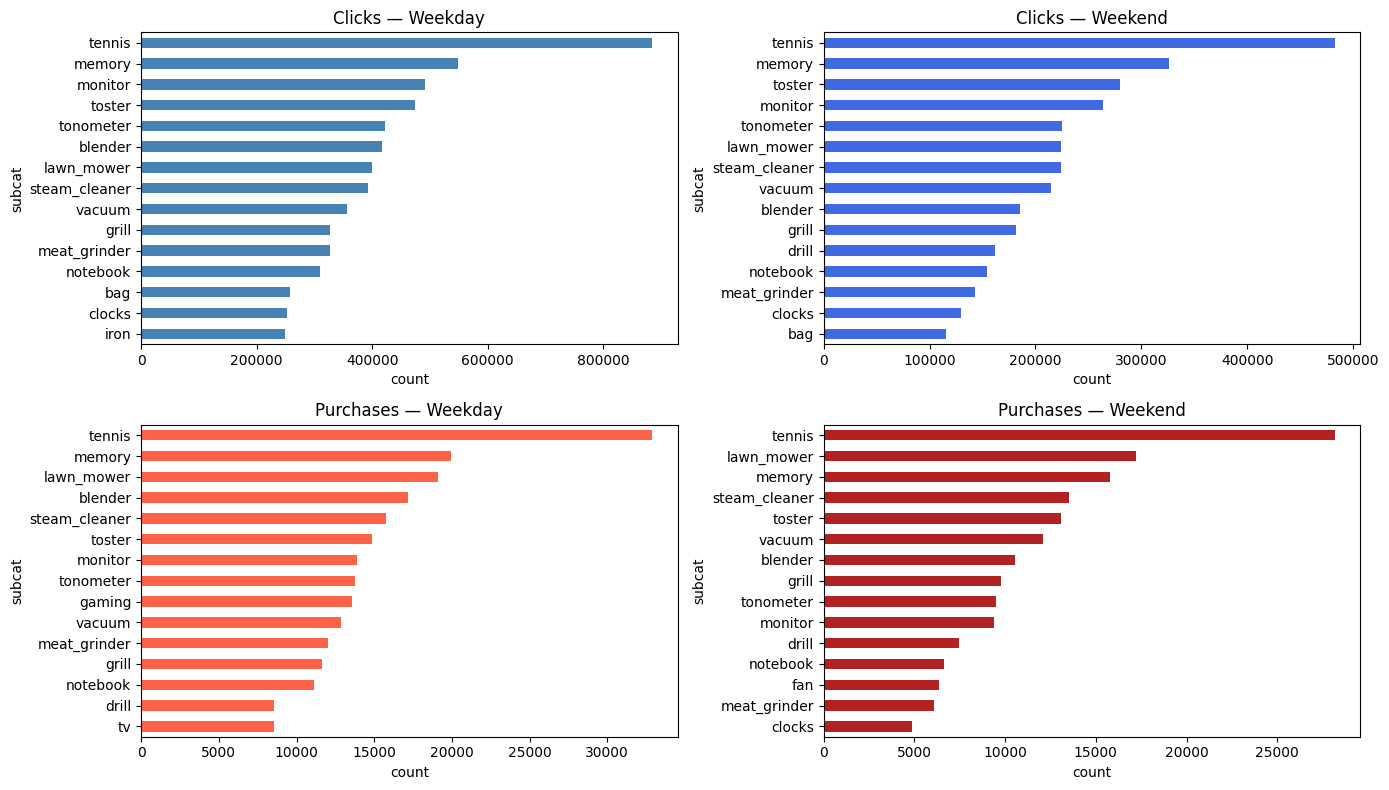

In [34]:
# Compare top clicked/purchased subcategories week vs weekend
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    (clicks_week,      'Clicks — Weekday',   axes[0,0], 'steelblue'),
    (clicks_weekend,   'Clicks — Weekend',   axes[0,1], 'royalblue'),
    (purchases_week,   'Purchases — Weekday',axes[1,0], 'tomato'),
    (purchases_weekend,'Purchases — Weekend',axes[1,1], 'firebrick'),
]
for df, title, ax, col in pairs:
    top = df['subcat'].value_counts().head(15)
    top.plot(kind='barh', ax=ax, color=col)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('count')

plt.tight_layout()
plt.savefig('top_items_week_weekend.png', dpi=120, bbox_inches='tight')
plt.show()

In [35]:
# print top-5 subcategories for each split
print('Top-5 clicked subcategories — Weekday :', clicks_week['subcat'].value_counts().index[:5].tolist())
print('Top-5 clicked subcategories — Weekend :', clicks_weekend['subcat'].value_counts().index[:5].tolist())
print('Top-5 purchased subcategories — Weekday :', purchases_week['subcat'].value_counts().index[:5].tolist())
print('Top-5 purchased subcategories — Weekend :', purchases_weekend['subcat'].value_counts().index[:5].tolist())

Top-5 clicked subcategories — Weekday : ['tennis', 'memory', 'monitor', 'toster', 'tonometer']
Top-5 clicked subcategories — Weekend : ['tennis', 'memory', 'toster', 'monitor', 'tonometer']
Top-5 purchased subcategories — Weekday : ['tennis', 'memory', 'lawn_mower', 'blender', 'steam_cleaner']
Top-5 purchased subcategories — Weekend : ['tennis', 'lawn_mower', 'memory', 'steam_cleaner', 'toster']


### Discussion
Tennis is the dominating subcategory in clicks and purchases at each time. In general, the difference between week and weekend is neglectable in both clicks an purchases.

## 2.2. Compute Frequent Itemsets

In [36]:
# Mine frequent itemsets for week and weekend splits
fi_cl_week  = mine_frequent_itemsets(te_cl_week,  min_support=S_MIN_CLICKS,    label='clicks-week')
fi_cl_wknd  = mine_frequent_itemsets(te_cl_wknd,  min_support=S_MIN_CLICKS,    label='clicks-weekend')
fi_pu_week  = mine_frequent_itemsets(te_pu_week,  min_support=S_MIN_PURCHASES, label='purchases-week')
fi_pu_wknd  = mine_frequent_itemsets(te_pu_wknd,  min_support=S_MIN_PURCHASES, label='purchases-weekend')

[clicks-week] min_support=0.0050  ->  239 frequent itemsets
   1-itemsets: 110
   2-itemsets: 128
   3-itemsets: 1
[clicks-weekend] min_support=0.0050  ->  269 frequent itemsets
   1-itemsets: 108
   2-itemsets: 152
   3-itemsets: 9
[purchases-week] min_support=0.0050  ->  188 frequent itemsets
   1-itemsets: 91
   2-itemsets: 93
   3-itemsets: 4
[purchases-weekend] min_support=0.0050  ->  172 frequent itemsets
   1-itemsets: 74
   2-itemsets: 85
   3-itemsets: 13


In [37]:
# Itemsets exclusive to weekday or weekend
def frozenset_str(fs):
    return frozenset(sorted(fs))

def itemset_diff(fi_a, fi_b, label_a, label_b):
    set_a = set(fi_a['itemsets'].apply(frozenset_str))
    set_b = set(fi_b['itemsets'].apply(frozenset_str))
    only_a = set_a - set_b
    only_b = set_b - set_a
    both   = set_a & set_b
    print(f'Itemsets only in {label_a}   : {len(only_a):,}')
    print(f'Itemsets only in {label_b}: {len(only_b):,}')
    print(f'Itemsets in both              : {len(both):,}')
    return only_a, only_b, both

print('=== CLICKS ===')
cl_only_week, cl_only_wknd, cl_both = itemset_diff(
    fi_cl_week, fi_cl_wknd, 'weekday', 'weekend')

print('\n=== PURCHASES ===')
pu_only_week, pu_only_wknd, pu_both = itemset_diff(
    fi_pu_week, fi_pu_wknd, 'weekday', 'weekend')

=== CLICKS ===
Itemsets only in weekday   : 5
Itemsets only in weekend: 35
Itemsets in both              : 234

=== PURCHASES ===
Itemsets only in weekday   : 31
Itemsets only in weekend: 15
Itemsets in both              : 157


## 2.3. Generate Association Rules from Frequent Itemsets

In [38]:
def generate_rules(fi, metric='confidence', min_threshold=0.3,
                   extra_metrics=True, label='', support_only=False):
    rules = association_rules(fi, metric=metric, min_threshold=min_threshold, support_only=support_only)
    if extra_metrics:
        # Conviction: infinity when rule is perfect; high when consequent is
        # much more likely given the antecedent.
        rules['conviction'] = rules.apply(
            lambda r: (1 - r['consequent support']) / (1 - r['confidence'])
                      if r['confidence'] < 1 else np.inf, axis=1)
    rules['ant_len'] = rules['antecedents'].apply(len)
    rules['con_len'] = rules['consequents'].apply(len)
    print(f'[{label}] metric={metric} threshold={min_threshold}  →  {len(rules):,} rules')
    return rules

In [39]:
C = 0.2
L = 1.1
# Generate rules for all four splits
rules_cl_week  = generate_rules(fi_cl_week,  min_threshold=C, label='clicks-week')
rules_cl_wknd  = generate_rules(fi_cl_wknd,  min_threshold=C, label='clicks-weekend')
rules_pu_week  = generate_rules(fi_pu_week,  min_threshold=C, label='purchases-week')
rules_pu_wknd  = generate_rules(fi_pu_wknd,  min_threshold=C, label='purchases-weekend')
print(len(rules_cl_week), len(rules_cl_wknd), len(rules_pu_week), len(rules_pu_wknd))


# Filter by lift
rules_cl_week  = rules_cl_week[rules_cl_week['lift']   >= L]
rules_cl_wknd  = rules_cl_wknd[rules_cl_wknd['lift']   >= L]
rules_pu_week  = rules_pu_week[rules_pu_week['lift']   >= L]
rules_pu_wknd  = rules_pu_wknd[rules_pu_wknd['lift']   >= L]

print(f'Final counts (C≥{C}, L≥{L}):')
print(f'  Click rules   weekday : {len(rules_cl_week):,}')
print(f'  Click rules   weekend : {len(rules_cl_wknd):,}')
print(f'  Purchase rules weekday: {len(rules_pu_week):,}')
print(f'  Purchase rules weekend: {len(rules_pu_wknd):,}')

[clicks-week] metric=confidence threshold=0.2  →  24 rules
[clicks-weekend] metric=confidence threshold=0.2  →  63 rules
[purchases-week] metric=confidence threshold=0.2  →  42 rules
[purchases-weekend] metric=confidence threshold=0.2  →  70 rules
24 63 42 70
Final counts (C≥0.2, L≥1.1):
  Click rules   weekday : 24
  Click rules   weekend : 59
  Purchase rules weekday: 40
  Purchase rules weekend: 63


In [40]:
# Rules unique to weekday or weekend
def rule_signature(row):
    return (frozenset(row['antecedents']), frozenset(row['consequents']))

def rule_diff(rules_a, rules_b, label_a='weekday', label_b='weekend'):
    sigs_a = set(rules_a.apply(rule_signature, axis=1))
    sigs_b = set(rules_b.apply(rule_signature, axis=1))
    print(f'Rules only in {label_a}  : {len(sigs_a - sigs_b):,}')
    print(f'Rules only in {label_b}: {len(sigs_b - sigs_a):,}')
    print(f'Rules in both           : {len(sigs_a & sigs_b):,}')

print('=== CLICK RULES ===')
rule_diff(rules_cl_week, rules_cl_wknd)
print('\n=== PURCHASE RULES ===')
rule_diff(rules_pu_week, rules_pu_wknd)

=== CLICK RULES ===
Rules only in weekday  : 2
Rules only in weekend: 37
Rules in both           : 22

=== PURCHASE RULES ===
Rules only in weekday  : 10
Rules only in weekend: 33
Rules in both           : 30


In [41]:
# Show top rules unique to weekday and weekend
def rules_unique_to(rules_main, rules_other, label):
    sigs_other = set(rules_other.apply(rule_signature, axis=1))
    mask = ~rules_main.apply(rule_signature, axis=1).isin(sigs_other)
    unique = rules_main[mask].sort_values('lift', ascending=False)
    unique = unique.head(10).copy()
    unique['antecedents'] = unique['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    unique['consequents'] = unique['consequents'].apply(lambda x: ', '.join(sorted(x)))
    print(f'\n=== Top-10 rules unique to {label} (by lift) ===')
    print(unique[['antecedents','consequents','support','confidence','lift']].to_string(index=False))

rules_unique_to(rules_cl_week, rules_cl_wknd, 'Click Weekday')
rules_unique_to(rules_cl_wknd, rules_cl_week, 'Click Weekend')
rules_unique_to(rules_pu_week, rules_pu_wknd, 'Purchase Weekday')
rules_unique_to(rules_pu_wknd, rules_pu_week, 'Purchase Weekend')


=== Top-10 rules unique to Click Weekday (by lift) ===
antecedents consequents  support  confidence   lift
         tv         bag   0.0086      0.2126 3.5875
 dishwasher      tennis   0.0051      0.2017 1.1406

=== Top-10 rules unique to Click Weekend (by lift) ===
       antecedents   consequents  support  confidence   lift
               cpu           fan   0.0056      0.2366 4.8543
       fan, tennis        memory   0.0072      0.5068 3.6778
     steam_cleaner         drill   0.0186      0.2215 3.4896
   blender, tennis        memory   0.0056      0.3866 2.8056
   memory, monitor        toster   0.0054      0.3311 2.8031
           bottles steam_cleaner   0.0083      0.2180 2.6004
      power_supply     tonometer   0.0087      0.2476 2.5734
 tennis, tonometer       monitor   0.0061      0.2830 2.4275
lawn_mower, memory        tennis   0.0050      0.4428 2.2816
   monitor, tennis     tonometer   0.0061      0.2139 2.2239

=== Top-10 rules unique to Purchase Weekday (by lift) ===
  

## 2.4. Take a Look at Maximal Patterns

In [46]:
def maximal_itemsets(fi_df):
    """Return only maximal frequent itemsets from a mlxtend fi DataFrame."""
    itemsets = fi_df['itemsets'].tolist()
    maximal  = []
    for i, s in enumerate(itemsets):
        is_max = True
        for j, t in enumerate(itemsets):
            if i != j and s < t:   # s is a proper subset of t
                is_max = False
                break
        if is_max:
            maximal.append(i)
    return fi_df.iloc[maximal].copy()


def show_maximal(max_df, label, n=10):
    top = max_df.sort_values('support', ascending=False).head(n).copy()
    top['itemsets'] = top['itemsets'].apply(lambda x: ', '.join(sorted(x)))
    print(f'\n=== Top-{n} Maximal Patterns — {label} ===')
    print(top[['itemsets','support','length']].to_string(index=False))


In [47]:
# Maximal patterns for week/weekend splits
max_cl_week = maximal_itemsets(fi_cl_week)
max_cl_wknd = maximal_itemsets(fi_cl_wknd)
max_pu_week = maximal_itemsets(fi_pu_week)
max_pu_wknd = maximal_itemsets(fi_pu_wknd)

for lbl, fi, mx in [
    ('Click Weekday',   fi_cl_week, max_cl_week),
    ('Click Weekend',   fi_cl_wknd, max_cl_wknd),
    ('Purchase Weekday',fi_pu_week, max_pu_week),
    ('Purchase Weekend',fi_pu_wknd, max_pu_wknd),
]:
    print(f'{lbl:25s}: {len(fi):4,} freq → {len(mx):4,} maximal')

Click Weekday            :  239 freq →  198 maximal
Click Weekend            :  269 freq →  212 maximal
Purchase Weekday         :  188 freq →  148 maximal
Purchase Weekend         :  172 freq →  122 maximal


In [48]:
show_maximal(max_cl_week, 'Click Weekday')
show_maximal(max_cl_wknd, 'Click Weekend')
show_maximal(max_pu_week, 'Purchase Weekday')
show_maximal(max_pu_wknd, 'Purchase Weekend')


=== Top-10 Maximal Patterns — Click Weekday ===
       itemsets  support  length
          chair   0.0362       1
      microwave   0.0309       1
   water_heater   0.0296       1
         ebooks   0.0282       1
     calculator   0.0250       1
monitor, tennis   0.0233       2
     compressor   0.0221       1
         cooler   0.0221       1
         router   0.0213       1
        climate   0.0208       1

=== Top-10 Maximal Patterns — Click Weekend ===
            itemsets  support  length
        water_heater   0.0271       1
          compressor   0.0212       1
               screw   0.0210       1
            massager   0.0203       1
              cooler   0.0200       1
             climate   0.0198       1
              router   0.0196       1
                sofa   0.0192       1
    notebook, tennis   0.0190       2
drill, steam_cleaner   0.0186       2

=== Top-10 Maximal Patterns — Purchase Weekday ===
                 itemsets  support  length
       lawn_mower, tennis 

## 2.5. Conclusions from Mining Frequent Patterns in Week and Weekend (Local Patterns and Rules)
The following analysis is done for all rules with a threshhold of condidence >= 0.2 and lift >= 1.2.
### Association Rules

Click rules show almost no weekday-specific behaviour, because no rules are unique to weekdays, and the two weekend-only click rules (`lawn_mower → tennis`, `tonometer → tennis`) are weak (lift ≈ 1.15–1.39). 

In the purchase rules, the single weekday-only rule (`monitor → tennis`, lift 1.18) is marginal and likely reflects a niche segment. Weekend-only purchase rules are far richer: eight rules emerge, with notably higher lift. The strongest is a bidirectional association between `steam_cleaner` and `drill`, which suggests weekend shoppers frequently buy both in the same session regardless of which they considered first. These two items could be bundled in the online shop, i.e., offering them together. `grill` appears as a consequent in three separate rules (`vacuum`, `tonometer`, `lawn_mower`), and seems to reinforce a home/outdoor spending theme unique to weekends.

### Maximal Patterns

Click maximal patterns are almost entirely length-1 on both days, with nearly identical compositions. This confirms that co-browsing is diffuse, no pair of subcategories dominates click sessions enough to form a stable frequent 2-itemset.

Purchase maximal patterns are where the weekday/weekend split is most visible. Weekday patterns are all length-1 except for `lawn_mower, tennis`. At weekends, five of the top-10 maximal patterns are length-2, including `memory, tennis`, `fan, memory`, `tennis, toster`, and `grill, lawn_mower`. The recurring presence of `tennis` across multiple weekend maximal patterns marks it as the strongest single differentiator between weekday and weekend purchase behaviour.




In [3]:
import nbformat
from nbconvert import HTMLExporter

with open("notebook.ipynb") as f:
    nb = nbformat.read(f, as_version=4)

html_exporter = HTMLExporter()
(body, resources) = html_exporter.from_notebook_node(nb)

with open("notebook.html", "w") as f:
    f.write(body)

ModuleNotFoundError: No module named 'nbconvert'